#### Prelimnary Analysis - Seaborn + plotly
<pre>
1) Check null values and duplicates in each df. Create Functions for the same
2) Find Count of Customers from each city and represent it on bar chart.
3) Find Range Age wise count of cutsomers, represent it on pie chart. 
4) Find Count of each activity, represent it on bar chart
5) Find order month wise total amount. Represent it on line chart.
6) Find Sub_Plan wise total revenue generated. Represent it on bar chart.
7) City wise find total amount
8) Find count of each payment mode, represent it on donut chart
9) Represent Payment mode wise sum of amount on a strip plot

</pre>
#### Objective - Funnel Analysis
<pre>
1) Generate the Entire Funnel. Represent 4 columns
- Funnel_Stage, Count_of_Cust, Percenatge_Conversion

2) Find Customer wise count of days to transition from one stage of funnel to the next stage

3) Find Avg_Days to transition from one Funnel stage to the next stage.

4) Create function to analyse Funnel based on City. 

</pre>


In [1]:
!pip install plotly

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
ca = pd.read_csv('cust_activity.csv')
cb = pd.read_csv('cust_bio.csv')
cs = pd.read_csv('cust_sub.csv')
sp = pd.read_csv('sp.csv')
orders = pd.read_csv('orders.csv')


In [4]:
for i in [ca,cb,cs,sp,orders]:
    print(i.shape)

(7500, 3)
(478, 3)
(51, 3)
(6, 5)
(127, 4)


In [6]:
def check_null_dup(data):
    nv=data.isnull().sum()
    dup=data.duplicated().sum()
    if dup>0:
        print(nv)
    else:
        print('No duplicates')
    if nv[nv>0].shape[0]>0:
        print(nv)
    else:
        print('no null values')

In [7]:
for i in [ca,cb,cs,sp,orders]:
    check_null_dup(i)

No duplicates
no null values
No duplicates
no null values
No duplicates
no null values
No duplicates
no null values
No duplicates
no null values


In [8]:
for i in[ca,cb,cs,sp,orders]:
    print(i.columns)

Index(['Cust_ID', 'Activity', 'Date'], dtype='object')
Index(['Cust_ID', 'City', 'Age'], dtype='object')
Index(['Cust_ID', 'Plan_Var_ID', 'Purchase_Date'], dtype='object')
Index(['Plan_Var_ID', 'Plan_ID', 'Plan_name', 'Price', 'Duration'], dtype='object')
Index(['Order_id', 'Cust_ID', 'Amount', 'Payment_mode'], dtype='object')


In [16]:
q1 =cb['City'].value_counts().reset_index()
q1

,City,count
0,Chennai,109
1,Delhi,106
2,Kolkata,94
3,Noida,92
4,Mumbai,77


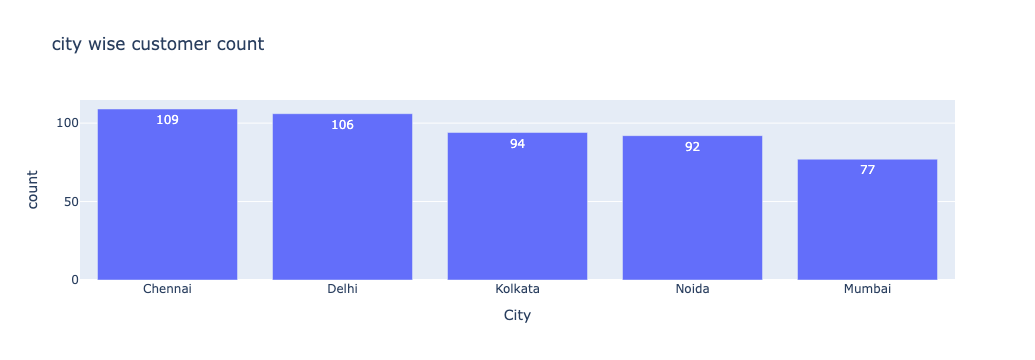

In [20]:
fig= px.bar(data_frame=q1,x='City',y='count',text='count',title='city wise customer count')
fig.show()

In [ ]:
binning: binning means converting numeric into categorical data 

In [21]:
# Find Range Age wise count of cutsomers, represent it on pie chart. 
cb['Age'].describe()

count    478.000000
mean      28.740586
std        5.376756
min       20.000000
25%       24.000000
50%       29.000000
75%       34.000000
max       37.000000
Name: Age, dtype: float64

In [22]:
cb['Age_Range']=pd.cut(cb['Age'],bins=[19,22,25,28,31,34,37])
cb['Age_Range']=cb['Age_Range'].astype(str)
cb['Age_Range'].value_counts()

Age_Range
(34, 37]    91
(31, 34]    87
(19, 22]    84
(25, 28]    73
(28, 31]    72
(22, 25]    71
Name: count, dtype: int64

In [26]:
q3=cb['Age_Range'].value_counts().reset_index()
q3['Per']=(q3['count']/q3['count'].sum())*100
q3

,Age_Range,count,Per
0,"(34, 37]",91,19.037657
1,"(31, 34]",87,18.200837
2,"(19, 22]",84,17.573222
3,"(25, 28]",73,15.271967
4,"(28, 31]",72,15.062762
5,"(22, 25]",71,14.853556


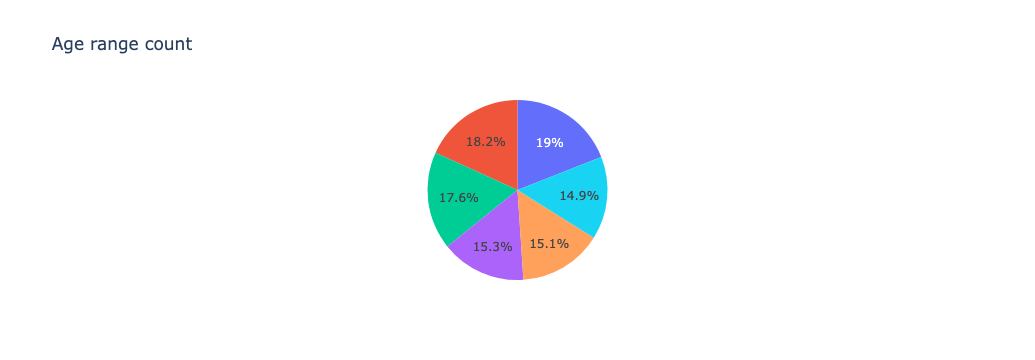

In [27]:
fig=px.pie(data_frame=q3,values='count',labels='Age_Range',title='Age range count' )
fig.show()

In [40]:
# Find Count of each activity, represent it on bar chart
q6= ca['Activity'].value_counts().reset_index()
q6

,Activity,count
0,Browse,6548
1,Sign_Up,478
2,Add_to_Cart,287
3,Checkout,127
4,Review,40
5,Return/Refund,20


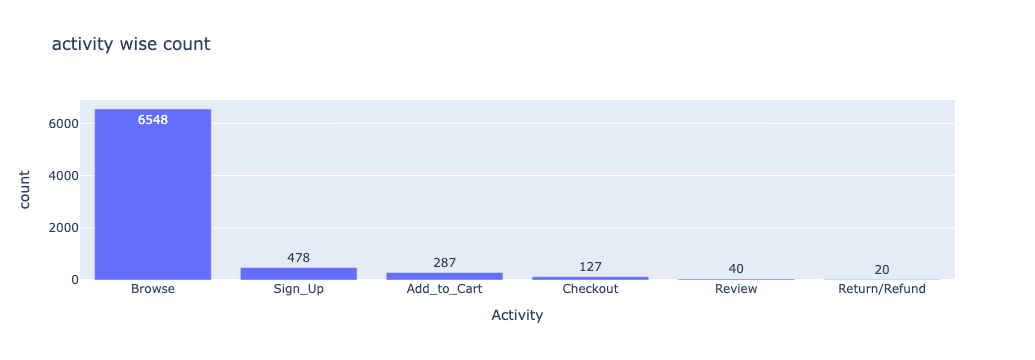

In [41]:
fig= px.bar(data_frame=q6,x='Activity',y='count',text='count',title='activity wise count')
fig.show()

In [43]:
ca_checkout=ca[ca['Activity']=='Checkout']
ca_checkout.shape

(127, 3)

In [44]:
#Find order month wise total amount. Represent it on line chart.
t5=pd.merge(ca_checkout,orders,on='Cust_ID',how='inner')
print(t5.shape)
t5.head()


(127, 6)


,Cust_ID,Activity,Date,Order_id,Amount,Payment_mode
0,CUS_121,Checkout,2024-05-05,ORD_83,3336.69,UPI
1,CUS_127,Checkout,2024-06-16,ORD_172,6427.90,Credit_Card
2,CUS_129,Checkout,2025-04-02,ORD_97,8653.62,UPI
3,CUS_135,Checkout,2024-08-02,ORD_87,2551.37,Credit_Card
4,CUS_139,Checkout,2024-10-12,ORD_127,3290.14,UPI


In [45]:
t5['Date']=pd.to_datetime(t5['Date'])


In [46]:
t5['Order_Month']=t5['Date'].dt.month

In [49]:
q5= t5.groupby(['Order_Month'])['Amount'].sum().reset_index()
q5

,Order_Month,Amount
0,1,27022.20
1,2,70477.42
2,3,74777.59
3,4,88080.66
4,5,60200.46
5,6,69580.07
6,7,80416.05
7,8,27227.29
8,9,34804.62
9,10,30298.38


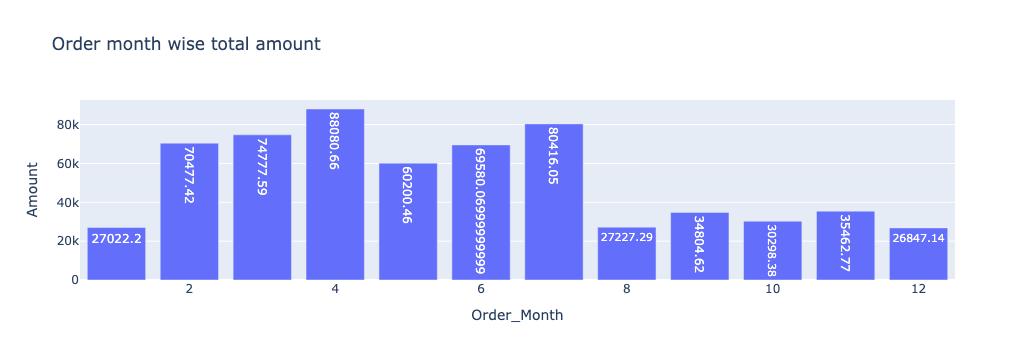

In [50]:
fig=px.bar(data_frame=q5,x='Order_Month',y='Amount',text='Amount',title='Order month wise total amount')
fig.show()

In [51]:
# Find Sub_Plan wise total revenue generated. Represent it on bar chart.

t6=pd.merge(sp,cs,on='Plan_Var_ID',how='inner')
print(t6.shape)
t6.head()

(51, 7)


,Plan_Var_ID,Plan_ID,Plan_name,Price,Duration,Cust_ID,Purchase_Date
0,P1_1Y,P1,Silver,1200.0,1 Year,CUS_626,2025-05-15
1,P1_1Y,P1,Silver,1200.0,1 Year,CUS_723,2024-07-23
2,P1_1Y,P1,Silver,1200.0,1 Year,CUS_575,2024-11-14
3,P1_1Y,P1,Silver,1200.0,1 Year,CUS_244,2025-07-12
4,P1_1Y,P1,Silver,1200.0,1 Year,CUS_294,2024-12-13


In [55]:
q6=t6.groupby(['Plan_ID'])['Price'].sum().reset_index()
q6

,Plan_ID,Price
0,P1,21840.0
1,P2,31200.0
2,P3,54720.0


In [61]:
import plotly.graph_objects as go

In [62]:
q8=orders['Payment_mode'].value_counts().reset_index()
q8

,Payment_mode,count
0,Net Banking,29
1,Debit Card,27
2,UPI,24
3,Credit_Card,24
4,COD,23


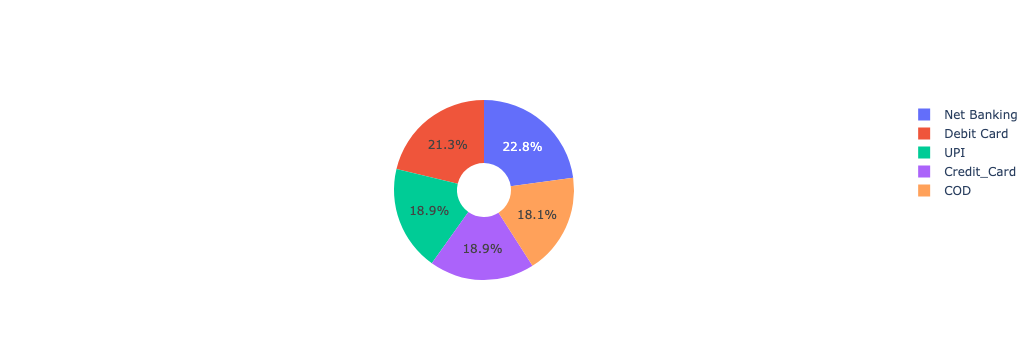

In [64]:
fig=go.Figure(data=[go.Pie(labels=q8['Payment_mode'],values=q8['count'],hole=.3)])
fig.show()

In [ ]:
# funnel ana;ysis 

In [67]:
ca['Activity'].value_counts()

Activity
Browse           6548
Sign_Up           478
Add_to_Cart       287
Checkout          127
Review             40
Return/Refund      20
Name: count, dtype: int64

In [66]:
f1=ca.groupby(['Cust_ID','Activity'])['Activity'].count().reset_index(name='Count')
f1.head()

,Cust_ID,Activity,Count
0,CUS_121,Add_to_Cart,1
1,CUS_121,Browse,8
2,CUS_121,Checkout,1
3,CUS_121,Sign_Up,1
4,CUS_122,Browse,10


In [74]:
funnel=f1['Activity'].value_counts().reset_index()
funnel

,Activity,count
0,Browse,681
1,Sign_Up,478
2,Add_to_Cart,287
3,Checkout,127
4,Review,40
5,Return/Refund,20


In [75]:
 funnel['Prev_Count']=np.where(funnel['Activity']=='Return/Refund',funnel['count'].shift(2),
                              funnel['count'].shift(1))
# funnel=funnel.fillna(0)

funnel

,Activity,count,Prev_Count
0,Browse,681,NaN
1,Sign_Up,478,681.0
2,Add_to_Cart,287,478.0
3,Checkout,127,287.0
4,Review,40,127.0
5,Return/Refund,20,127.0


In [78]:
funnel['Per_con']= (funnel['count']/funnel['Prev_Count'])*100
funnel=funnel.fillna(0)
funnel 

,Activity,count,Prev_Count,Per_con
0,Browse,681,0.0,0.000000
1,Sign_Up,478,681.0,70.190896
2,Add_to_Cart,287,478.0,60.041841
3,Checkout,127,287.0,44.250871
4,Review,40,127.0,31.496063
5,Return/Refund,20,127.0,15.748031


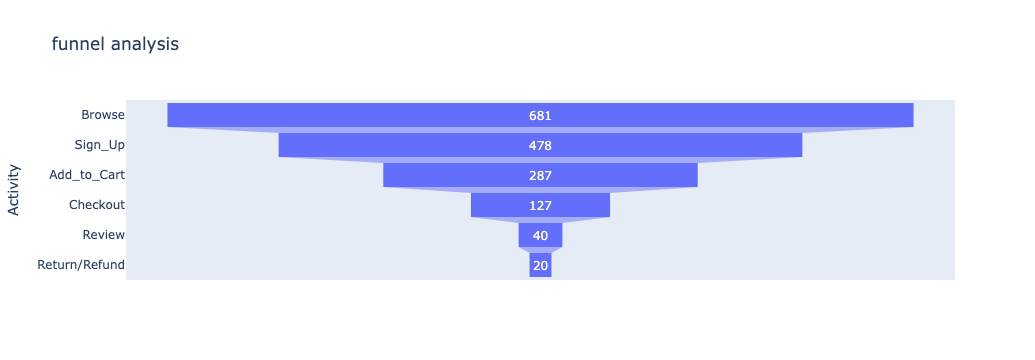

In [84]:
fig=px.funnel(data_frame=funnel,y='Activity',x='count',hover_data='Per_con',
            title='funnel analysis')
fig.show()

In [85]:
 # Find Customer wise count of days to transition from one stage of funnel to the next stage
ca['Date']=pd.to_datetime(ca['Date'])

In [86]:
pt1=pd.pivot_table(data=ca,index=['Cust_ID'],columns=['Activity'],values='Date',
                  aggfunc='min')
pt1

Activity,Add_to_Cart,Browse,Checkout,Return/Refund,Review,Sign_Up
Cust_ID,,,,,,
CUS_121,2024-04-27,2024-04-27,2024-05-05,NaT,NaT,2024-04-24
CUS_122,NaT,2025-07-12,NaT,NaT,NaT,NaT
CUS_123,NaT,2024-04-14,NaT,NaT,NaT,NaT
CUS_124,2025-01-06,2025-01-06,NaT,NaT,NaT,2025-01-05
CUS_125,NaT,2024-06-17,NaT,NaT,NaT,2024-06-15
...,...,...,...,...,...,...
CUS_797,NaT,2024-03-19,NaT,NaT,NaT,2024-03-15
CUS_798,NaT,2025-03-22,NaT,NaT,NaT,2025-03-19
CUS_799,NaT,2025-07-12,NaT,NaT,NaT,NaT


In [88]:
pt1['Signup_2Browse_DD']=abs(pt1['Sign_Up']-pt1['Browse']).dt.days
pt1['Add2Cart_2Signup_DD']=(pt1['Add_to_Cart']-pt1['Sign_Up']).dt.days
pt1['Checkout_2Add2Cart_DD']=(pt1['Checkout']-pt1['Add_to_Cart']).dt.days
pt1['Review_2Checkout_DD']=(pt1['Review']-pt1['Checkout']).dt.days
pt1['RR2_2Checkout_DD']=(pt1['Return/Refund']-pt1['Checkout']).dt.days
pt1.head()

Activity,Add_to_Cart,Browse,Checkout,Return/Refund,Review,Sign_Up,Signup_2Browse_DD,Add2Cart_2Signup_DD,Checkout_2Add2Cart_DD,Review_2Checkout_DD,RR2_2Checkout_DD
Cust_ID,,,,,,,,,,,
CUS_121,2024-04-27,2024-04-27,2024-05-05,NaT,NaT,2024-04-24,3.0,3.0,8.0,NaN,NaN
CUS_122,NaT,2025-07-12,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN
CUS_123,NaT,2024-04-14,NaT,NaT,NaT,NaT,NaN,NaN,NaN,NaN,NaN
CUS_124,2025-01-06,2025-01-06,NaT,NaT,NaT,2025-01-05,1.0,1.0,NaN,NaN,NaN
CUS_125,NaT,2024-06-17,NaT,NaT,NaT,2024-06-15,2.0,NaN,NaN,NaN,NaN


In [89]:
pt2=pt1.iloc[:,-5:]
pt2.mean()

Activity
Signup_2Browse_DD         2.516736
Add2Cart_2Signup_DD       2.512195
Checkout_2Add2Cart_DD    14.425197
Review_2Checkout_DD       2.625000
RR2_2Checkout_DD          3.400000
dtype: float64

In [90]:
dd_mean=[0]+ list(pt2.mean().values)
dd_mean

[0, 2.51673640167364, 2.5121951219512195, 14.4251968503937, 2.625, 3.4]

In [91]:
funnel['Avg_DayDiff']=dd_mean
funnel

,Activity,count,Prev_Count,Per_con,Avg_DayDiff
0,Browse,681,0.0,0.000000,0.000000
1,Sign_Up,478,681.0,70.190896,2.516736
2,Add_to_Cart,287,478.0,60.041841,2.512195
3,Checkout,127,287.0,44.250871,14.425197
4,Review,40,127.0,31.496063,2.625000
5,Return/Refund,20,127.0,15.748031,3.400000
